In [1]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

# Nodes

In [2]:
class State(TypedDict):
    nlist: List[str]

In [3]:
def node_a(state: State) -> State:
    print(f"node a is receiving {state['nlist']}")
    note = "Hello World from Node a"
    return(State(nlist = [note]))

In [ ]:
builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_edge(START, "a")
builder.add_edge("a", END)
graph = builder.compile()

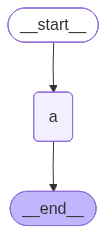

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))
# print(graph.get_graph().draw_mermaid())

In [ ]:
initial_state = State(
    nlist = ["Hello Node a, how are you?"]
)
graph.invoke(initial_state)

node a is receiving ['Hello Node a, how are you?']


{'nlist': ['Hello World from Node a']}

# Edges

In [9]:
class EdgeState(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [10]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return(EdgeState(nlist = ["A"]))

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return(EdgeState(nlist = ["B"]))

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return(EdgeState(nlist = ["C"]))

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return(EdgeState(nlist = ["BB"]))

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return(EdgeState(nlist = ["CC"]))

def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['nlist']}")
    return(EdgeState(nlist = ["D"]))

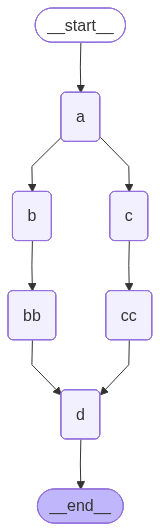

In [11]:
builder = StateGraph(EdgeState)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("bb", node_bb)
builder.add_node("cc", node_cc)
builder.add_node("d", node_d)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "bb")
builder.add_edge("c", "cc")
builder.add_edge("bb", "d")
builder.add_edge("cc", "d")
builder.add_edge("d",END)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
initial_state = EdgeState(
    nlist = ["Initial String:"]
)
graph.invoke(initial_state)

Adding 'A' to ['Initial String:']
Adding 'B' to ['Initial String:', 'A']
Adding 'C' to ['Initial String:', 'A']
Adding 'BB' to ['Initial String:', 'A', 'B', 'C']
Adding 'CC' to ['Initial String:', 'A', 'B', 'C']
Adding 'D' to ['Initial String:', 'A', 'B', 'C', 'BB', 'CC']


{'nlist': ['Initial String:', 'A', 'B', 'C', 'BB', 'CC', 'D']}

# Condition

In [13]:
class ConditionalState(TypedDict):
    nlist : Annotated[list[str], operator.add]   

In [14]:
def node_a(state: ConditionalState) -> Command[Literal["b", "c", END]]:
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        next_node = END

    return Command(
        update = ConditionalState(nlist = [select]),
        goto = [next_node]
    )

# def node_a(state: State):
#     return

def node_b(state: ConditionalState) -> ConditionalState:
    return(ConditionalState(nlist = ["B"]))
    
def node_c(state: ConditionalState) -> ConditionalState:
    return(ConditionalState(nlist = ["C"]))

In [15]:
def conditional_edge(state: ConditionalState) -> Literal["b", "c", END]:
    select = state["nlist"][-1]
    if select == "b":
        return "b"
    elif select == "c":
        return "c"
    elif select == "q":
        return END
    else:
        return END

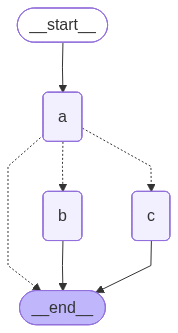

In [16]:
builder = StateGraph(ConditionalState)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)
# builder.add_conditional_edges("a", conditional_edge)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
user = input('b, c, or q to quit: ')

input_state = ConditionalState(
    nlist = [user]
)
graph.invoke(input_state)

{'nlist': ['q', 'q']}

In [20]:
while True:
    user = input('b, c, or q to quit: ')
    print(user)
    input_state = State(nlist =  [user])
    result = graph.invoke(input_state)
    print( result )
    if result['nlist'][-1] == "q":
        print("quit")
        break

b
{'nlist': ['b', 'b', 'B']}
e
{'nlist': ['e', 'e']}
q
{'nlist': ['q', 'q']}
quit


# Memory

In [22]:
memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

In [23]:
graph = builder.compile(checkpointer=memory)

In [25]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = State(nlist = [user])
    result = graph.invoke(input_state, config )
    print( result )
    if result['nlist'][-1] == "q":
        print("quit")
        break

{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'q', 'q', 'c', 'c', 'C']}
{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'q', 'q', 'c', 'c', 'C', 'q', 'q']}
quit


# HITL

In [2]:
memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

In [3]:
class HITLState(TypedDict):
    nlist : Annotated[list[str], operator.add]  

In [4]:
def node_a(state: HITLState) -> Command[Literal["b", "c", END]]:
    print("Entered 'a' node")
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        admin = interrupt(f"Unexpected input '{select}'")
        print(admin)
        if admin == "continue":
            next_node = "b"
        else:
            next_node = END
            select = "q"
            
    return Command(
        update = HITLState(nlist = [select]),
        goto = next_node
    )


def node_b (state: HITLState) -> HITLState:
    return(HITLState(nlist = ["B"]))

def node_c (state: HITLState) -> HITLState:
    return(HITLState(nlist = ["C"]))

In [5]:
builder = StateGraph(HITLState)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("b", END)
builder.add_edge("c", END)

# Compile
graph = builder.compile(checkpointer=memory)

In [7]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = HITLState(nlist = [user])
    result = graph.invoke(input_state, config)

    if '__interrupt__' in result:
        print(f"Interrupt:{result}")
        msg = result['__interrupt__'][-1].value
        print(msg)
        human = input(f"\n{msg}: ")

        human_response = Command(
            resume = human
        )
        result = graph.invoke(human_response, config)
        
    if result['nlist'][-1] == "q":
        print("quit")
        break


Entered 'a' node
Entered 'a' node
Entered 'a' node
Entered 'a' node
Interrupt:{'nlist': ['b', 'b', 'B', 'b', 'b', 'B', 'c', 'c', 'C', 'g'], '__interrupt__': [Interrupt(value="Unexpected input 'g'", id='8b5ca84e29e8285e2be5bc1d7d597c0a')]}
Unexpected input 'g'
Entered 'a' node

quit
